**Customer Churn Prediction using Machine Learning**

**Dataset:** IBM Telco Customer Churn Dataset

**Language:** Python

**Libraries:** Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, joblib

**Problem Type:** Binary Classification

**Objective**

The objective of this project is to predict whether a customer is likely to churn based on demographic, account, and service-related information.

In [317]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [318]:
df = pd.read_excel('/kaggle/input/datasets/minnuf17/customer-churn/Telco_customer_churn.xlsx')

In [319]:
df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


**Exploratory Data Analysis (EDA)**

In [320]:
df.shape


(7043, 33)

In [321]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [322]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


**Data Cleaning & Preprocessing**

In [323]:
df.duplicated().sum()

np.int64(0)

In [324]:
#unique values in every column
for col in df.columns:
    print(f"{col}")
    print(df[col].unique())
    print("-"*50)

CustomerID
['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
--------------------------------------------------
Count
[1]
--------------------------------------------------
Country
['United States']
--------------------------------------------------
State
['California']
--------------------------------------------------
City
['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']
--------------------------------------------------
Zip Code
[90003 90005 90006 ... 96128 96134 96146]
--------------------------------------------------
Lat Long
['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']
--------------------------------------------------
Latitude
[33.964131 34.059281 34.048013 ... 40.346634 41.813521 39.191797]
--------------------------------------------------
Longitude
[-118.272783 -118.30742  -118.293953 .

In [325]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [326]:
df['Churn Label'].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

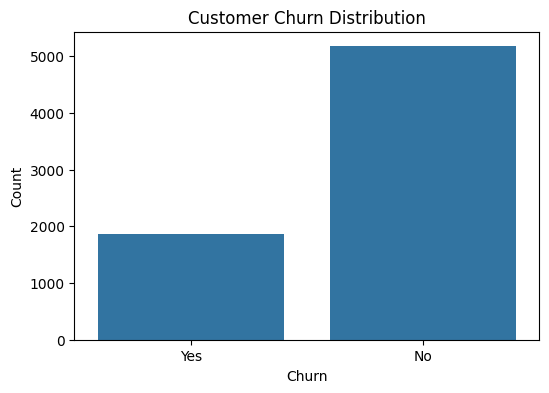

In [327]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn Label', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [328]:
#to check numercal columns
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

print(numerical_columns)

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='object')


In [329]:
#to check categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges', 'Churn Label', 'Churn Reason'],
      dtype='object')


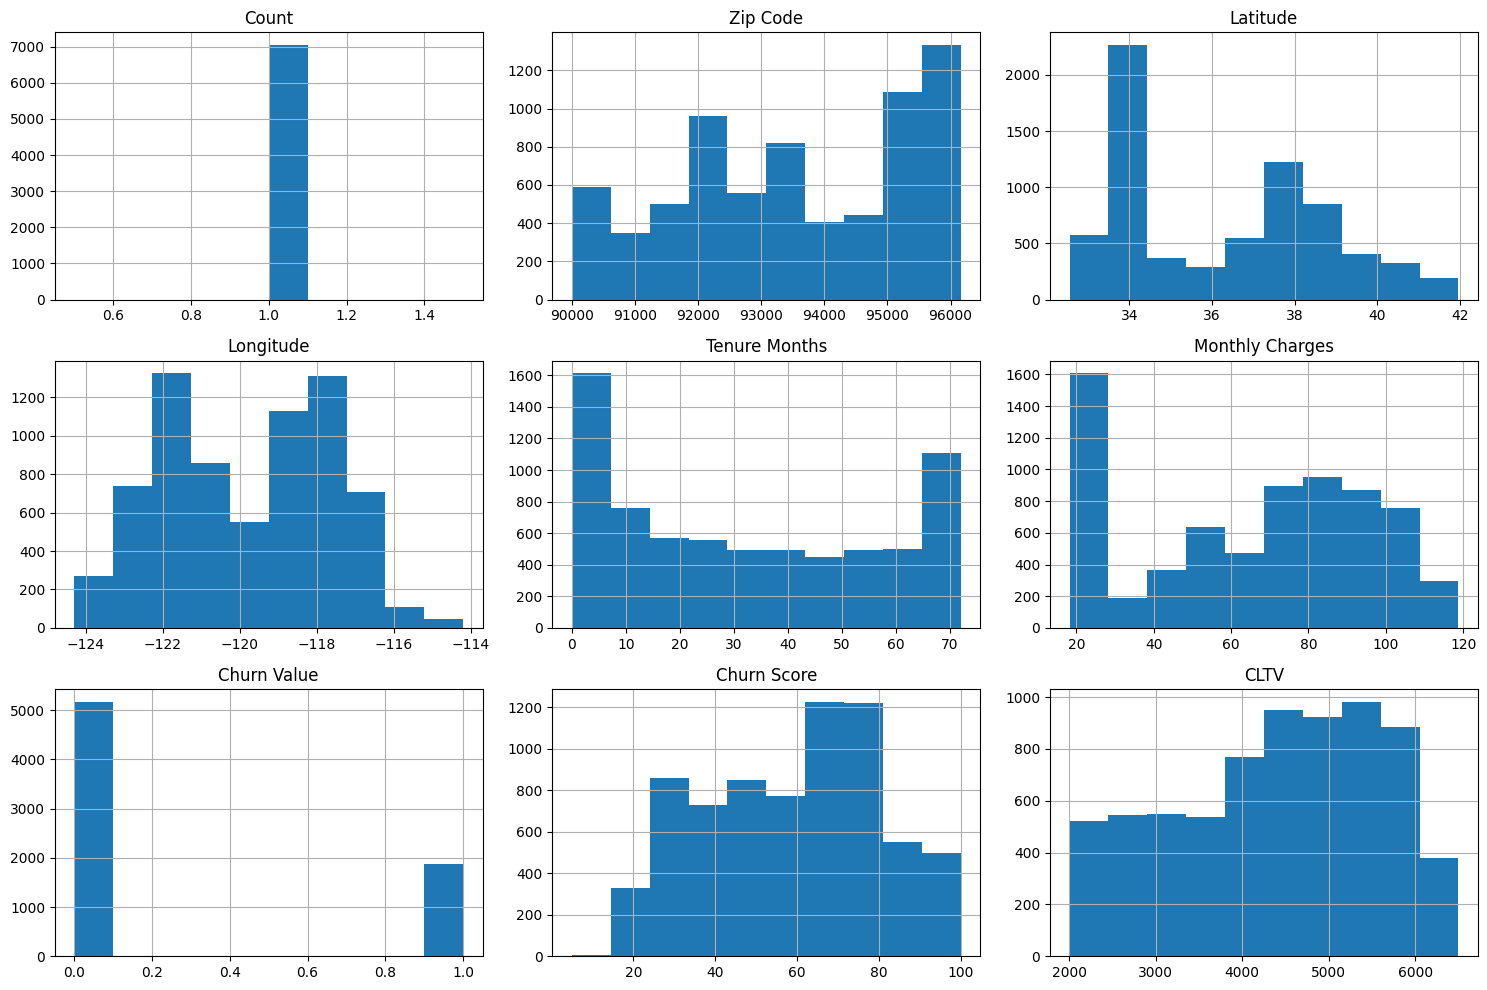

In [330]:
df.hist(figsize=(15,10))

plt.tight_layout()
plt.show()

In [331]:
numeric_df = df.select_dtypes(include=['number'])

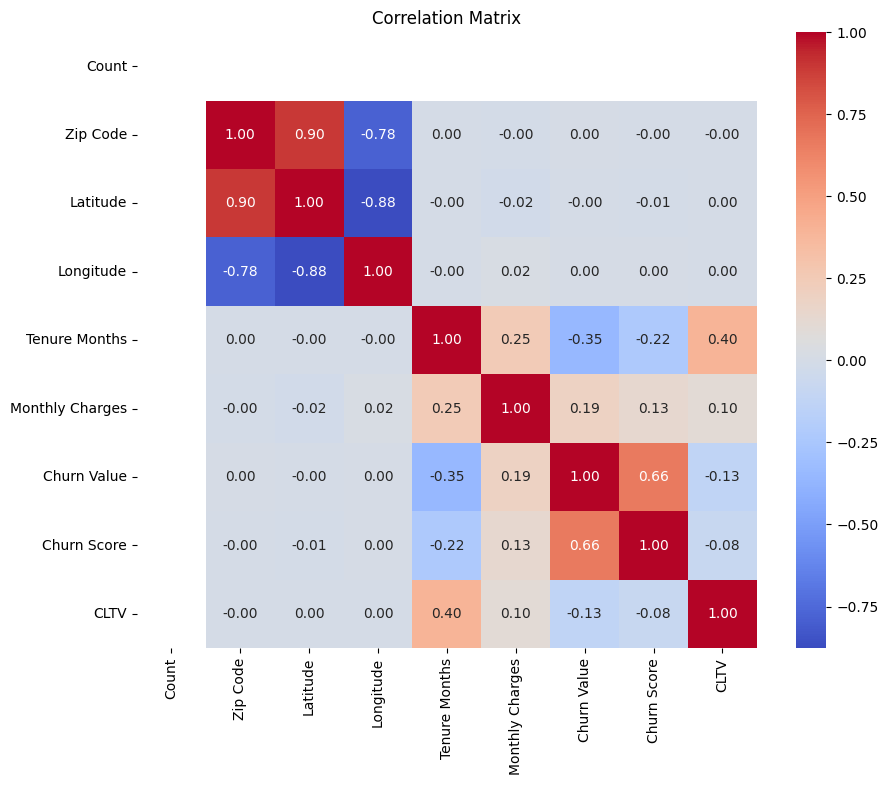

In [332]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


In [333]:
df['Total Charges'].dtype

dtype('O')

In [334]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [335]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [336]:
df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].median()
)

In [337]:
df.drop('CustomerID', axis=1, inplace=True)

In [338]:
df.dtypes

Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [339]:
x = df.drop(['Churn Label','Churn Value','Churn Score','Churn Reason','CLTV'], axis=1)
y = df["Churn Label"]

In [340]:
numerical_columns = x.select_dtypes(include=['int64', 'float64']).columns

categorical_columns = x.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Total Charges'],
      dtype='object')

Categorical Columns:
Index(['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')


In [341]:
from sklearn.preprocessing import LabelEncoder

In [342]:
le = LabelEncoder()
y = le.fit_transform(y)

In [343]:
#one-hot encoding
x = pd.get_dummies(
    x,
    columns=categorical_columns,
    drop_first=True
)

In [344]:
from sklearn.preprocessing import StandardScaler

In [345]:
scaler = StandardScaler()
x[numerical_columns] = scaler.fit_transform(
    x[numerical_columns]
)

In [346]:
x.head(5)

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,City_Acton,City_Adelanto,City_Adin,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,0.0,-1.886175,-0.944111,0.707268,-1.236724,-0.362660,-0.959674,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,0.0,-1.885103,-0.905362,0.691215,-1.236724,0.197365,-0.940470,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,0.0,-1.884567,-0.909951,0.697457,-0.992402,1.159546,-0.645186,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,0.0,-1.882423,-0.904204,0.687374,-0.177995,1.330711,0.337349,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,0.0,-1.879743,-0.913530,0.710276,0.677133,1.294151,1.216004,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [347]:
from sklearn.model_selection import train_test_split

In [348]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [349]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import (roc_curve,roc_auc_score)

**Logistic Regression**

In [350]:
la = LogisticRegression(random_state=42)

la.fit(x_train, y_train)

LogisticRegression(random_state=42)

In [351]:
y_prd = la.predict(x_test)

In [352]:
la.score(x_test, y_test)*100

79.4889992902768

In [353]:
log_accuracy = accuracy_score(y_test, y_prd)

print("Accuracy:", log_accuracy)

Accuracy: 0.794889992902768


In [354]:
#confusion matrix
cm = confusion_matrix(y_test, y_prd)

print(cm)

[[899 110]
 [179 221]]


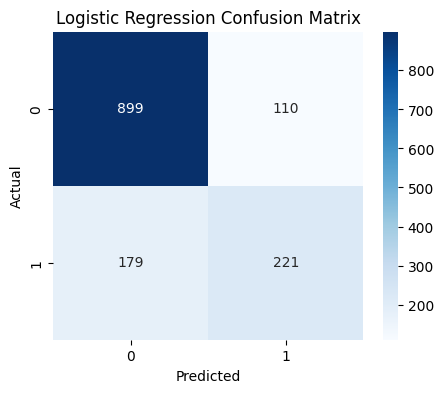

In [355]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [356]:
print(classification_report(y_test, y_prd))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1009
           1       0.67      0.55      0.60       400

    accuracy                           0.79      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



**K-Nearest Neighbors**

In [357]:
kn = KNeighborsClassifier(n_neighbors=5)

kn.fit(x_train, y_train)

KNeighborsClassifier()

In [358]:
y_prd_knn = kn.predict(x_test)

In [359]:
knn_accuracy = accuracy_score(y_test, y_prd_knn)

print("Accuracy:", knn_accuracy)

Accuracy: 0.7707594038325053


In [360]:
cm = confusion_matrix(y_test, y_prd_knn)

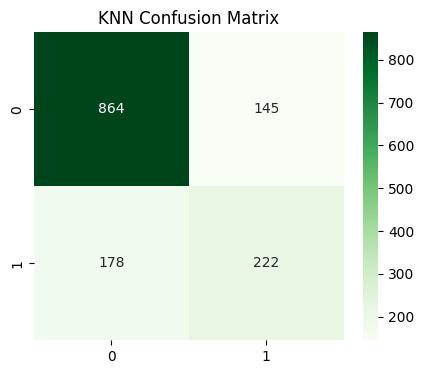

In [361]:
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
plt.title("KNN Confusion Matrix")
plt.show()

In [362]:
print(classification_report(y_test, y_prd_knn))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1009
           1       0.60      0.56      0.58       400

    accuracy                           0.77      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



**Decision Tree**

In [363]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [364]:
y_prd_tree = dt.predict(x_test)

In [365]:
tree_accuracy = accuracy_score( y_test,y_prd_tree)
print(tree_accuracy)

0.7686302342086586


In [366]:
cm = confusion_matrix(y_test,y_prd_tree)

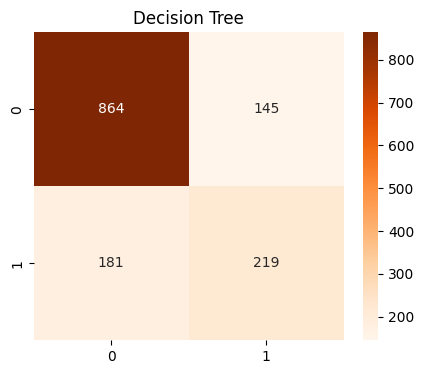

In [367]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges')

plt.title("Decision Tree")

plt.show()

In [368]:
print(classification_report(y_test,y_prd_tree))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1009
           1       0.60      0.55      0.57       400

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.76      0.77      0.77      1409



**Random Forest Classifier**

In [369]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)



RandomForestClassifier(random_state=42)

In [370]:
y_prd_rf = rf.predict(x_test)

In [371]:
rf_accuracy = accuracy_score(y_test,y_prd_rf)

print(rf_accuracy)

0.7963094393186657


In [372]:
cm = confusion_matrix( y_test,y_prd_rf)

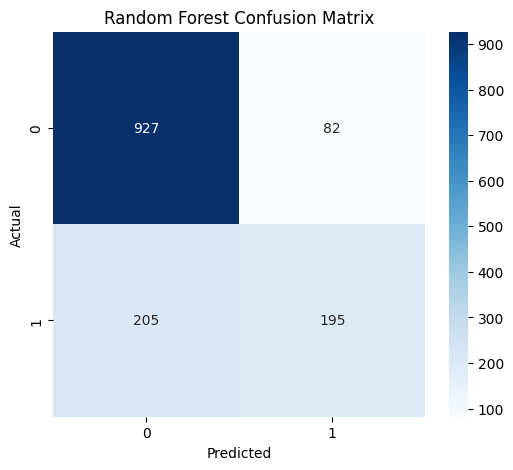

In [373]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [374]:
print(classification_report(y_test,y_prd_rf))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1009
           1       0.70      0.49      0.58       400

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.78      1409



**Model Comparison**

In [375]:
#COMPARE ALL MODELS
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        log_accuracy,
        knn_accuracy,
        tree_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.794890
1,KNN,0.770759
2,Decision Tree,0.768630
3,Random Forest,0.796309


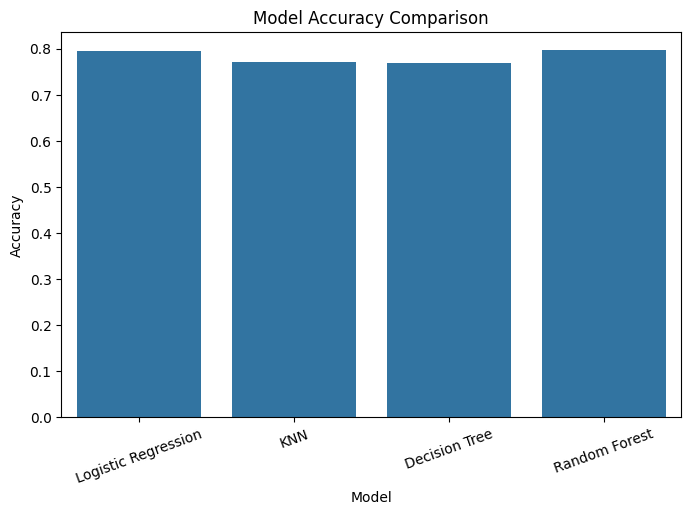

In [376]:
#PLOT MODELS COMPARISON
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

In [377]:
#BEST MODEL?
best_model = comparison.loc[
    comparison['Accuracy'].idxmax()
]

print("Best Model:")
print(best_model)

print(f"\nBest Accuracy: {best_model['Accuracy']:.2%}")

Best Model:
Model       Random Forest
Accuracy         0.796309
Name: 3, dtype: object

Best Accuracy: 79.63%


**ROC Curve & AUC**

In [378]:
from sklearn.metrics import (roc_curve,roc_auc_score)

In [379]:
#predict probabilities
y_prob = rf.predict_proba(x_test)[:,1]

In [380]:
#Calculate reciever operating characteristic curve(ROC curve) 
fpr, tpr, thresholds = roc_curve(y_test,y_prob)

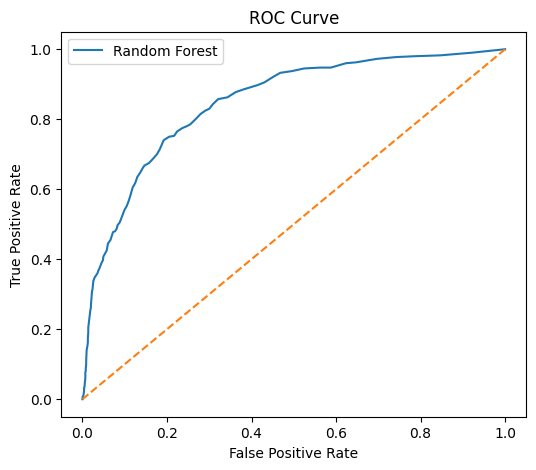

In [381]:
plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label='Random Forest')

plt.plot([0,1],[0,1],linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [382]:
#calculate AUC
auc = roc_auc_score(y_test,y_prob)

print("AUC Score:", auc)

AUC Score: 0.8465188305252727


**FEATURE IMPORTANCE**

In [383]:
importance = pd.DataFrame({
'Feature': x.columns,
'Importance': rf.feature_importances_

})

In [384]:
#sorting
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance.head(10)

,Feature,Importance
4,Tenure Months,0.072112
6,Total Charges,0.068085
5,Monthly Charges,0.049551
3,Longitude,0.038351
1,Zip Code,0.038186
2,Latitude,0.037731
2793,Internet Service_Fiber optic,0.025678
2808,Contract_Two year,0.022907
2811,Payment Method_Electronic check,0.021859
2789,Dependents_Yes,0.021503


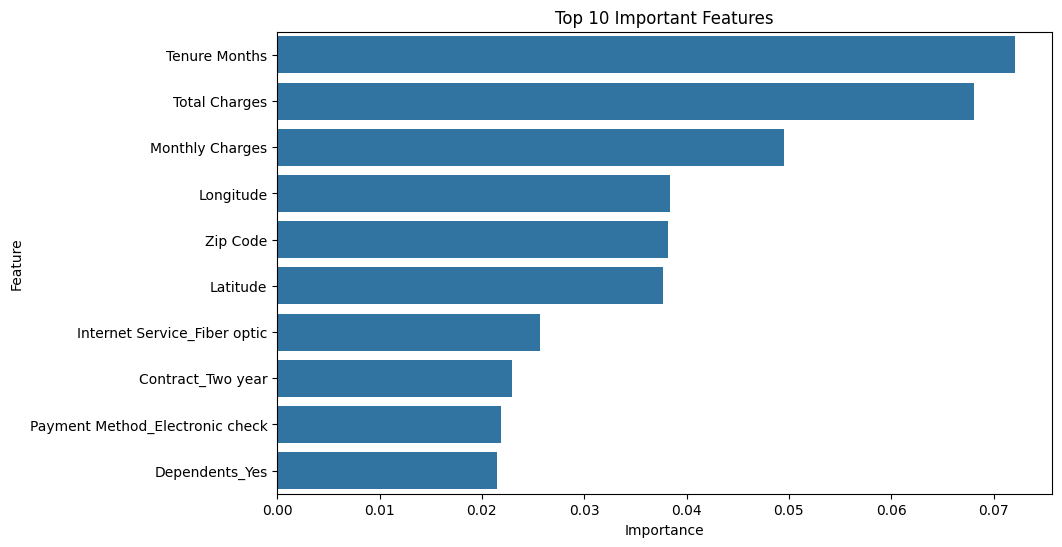

In [385]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()


**HYPER PARAMETER TUNING**

In [386]:
from sklearn.model_selection import GridSearchCV

In [387]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

In [388]:
rf = RandomForestClassifier(random_state=42)

In [389]:
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [390]:
#TRAIN GRID SEARCH
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [391]:
print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [392]:
print(grid.best_score_)

0.8031610667280272


In [393]:
best_rf = grid.best_estimator_

In [394]:
y_prd_best = best_rf.predict(x_test)

In [395]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_prd_best)

0.7963094393186657

**Cross Validation**

In [396]:
from sklearn.model_selection import cross_val_score

In [397]:
scores = cross_val_score(best_rf,x,y,cv=5)

In [398]:
print(scores)

[0.80056778 0.80340667 0.78211498 0.80326705 0.80752841]


In [399]:
print(scores.mean())

0.7993769759339312


**Save Model**

In [400]:
import joblib

In [401]:
joblib.dump(best_rf, "Customer_Churn_Model.pkl")

['Customer_Churn_Model.pkl']

In [402]:
#load the model
loaded_model = joblib.load(
    "Customer_Churn_Model.pkl"
)

In [403]:
#save feature importance
importance.to_csv(
    "Feature_Importance.csv",
    index=False
)

In [404]:
#save model comparison
comparison.to_csv(
    "Model_Comparison.csv",
    index=False
)

In [406]:
df.to_csv("Cleaned_Customer_Churn.csv", index=False)

**Conclusion**

In this project, an end-to-end machine learning pipeline was developed to predict customer churn using the IBM Telco Customer Churn dataset.

The workflow included:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Hyperparameter Tuning
- Cross Validation

Among all the evaluated models, the **Random Forest Classifier** achieved the best overall performance.

The project demonstrates how machine learning can help businesses identify customers who are likely to churn and support customer retention strategies.


**Evaluation Metrics**

The following metrics were used:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC